### Problem Statement : Design and implement Deep Convolutional GAN to generate images of faces/digits from a set of given images.

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import time

print(f"TensorFlow Version: {tf.__version__}")


TensorFlow Version: 2.19.0


In [2]:
# ==========================================
# Step 2: Prepare the dataset
# ==========================================
print("Loading and preprocessing the dataset...")
# Load the MNIST digits dataset
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

# Preprocess the images
# Reshape to (28, 28, 1) and normalize to the range [-1, 1] 
# (tanh activation in the generator requires [-1, 1])
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  

# Batch and shuffle the data
BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)


Loading and preprocessing the dataset...


In [3]:
# ==========================================
# Step 1: Initialize Generator and Discriminator
# ==========================================

def make_generator_model():
    model = tf.keras.Sequential()
    # Foundation for 7x7 image
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)

    # Upsample to 14x14
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsample to 14x14
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsample to 28x28 (Final Image Size)
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model

def make_discriminator_model():
    model = tf.keras.Sequential()
    # First Conv Layer
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Second Conv Layer
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Flatten and Classify (Real or Fake)
    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

# Instantiate the models
generator = make_generator_model()
discriminator = make_discriminator_model()

# ==========================================
# Loss Functions and Optimizers
# ==========================================
# Cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    # Generator wants the discriminator to think the fake images are real (1)
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)



C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting Training Loop...


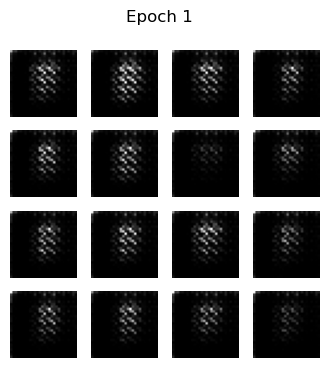

Time for epoch 1 is 150.86 sec


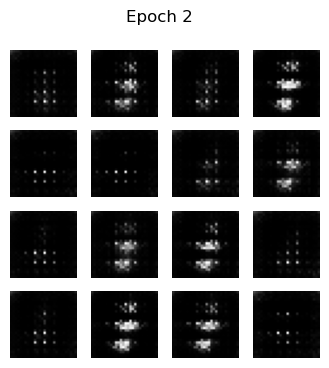

Time for epoch 2 is 163.39 sec


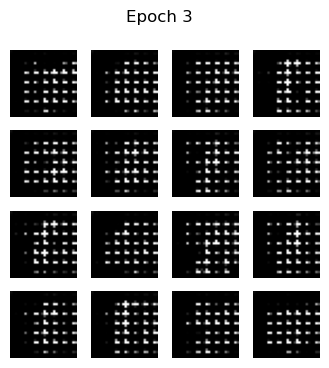

Time for epoch 3 is 169.66 sec


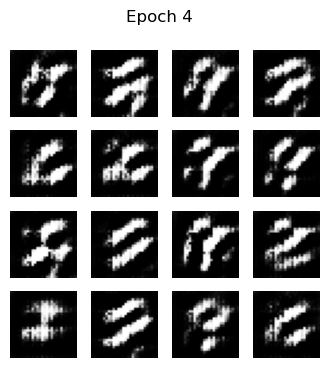

Time for epoch 4 is 172.97 sec


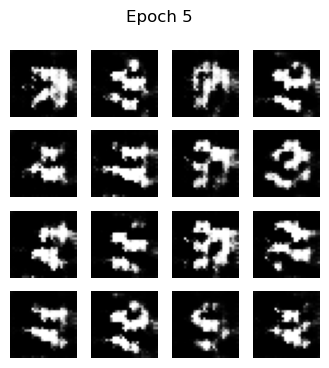

Time for epoch 5 is 164.33 sec


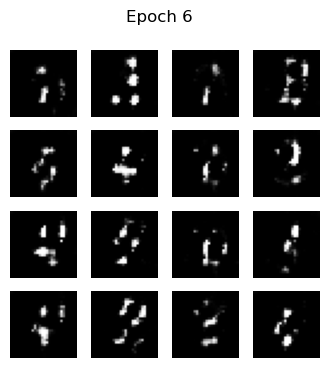

Time for epoch 6 is 166.59 sec


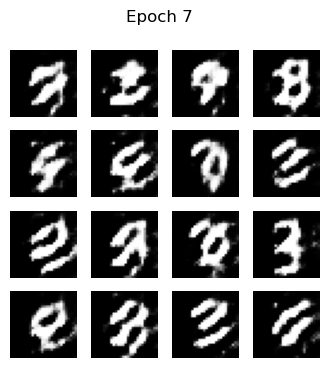

Time for epoch 7 is 165.75 sec


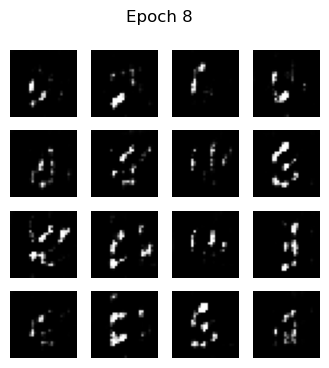

Time for epoch 8 is 169.71 sec


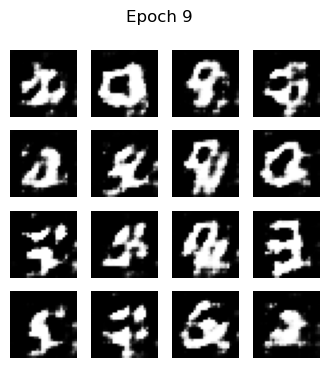

Time for epoch 9 is 169.28 sec


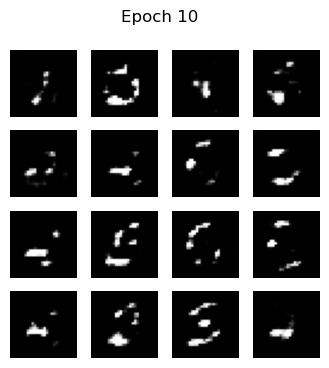

Time for epoch 10 is 165.97 sec


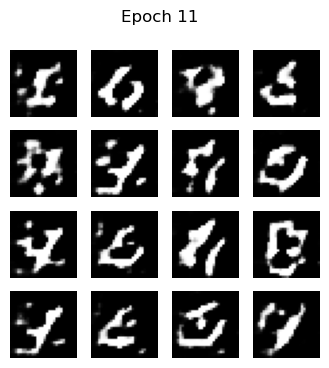

Time for epoch 11 is 169.25 sec


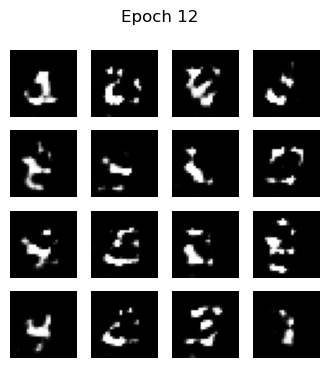

Time for epoch 12 is 169.03 sec


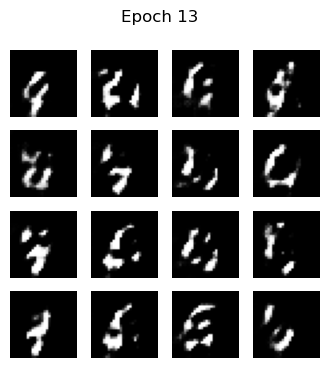

Time for epoch 13 is 167.18 sec


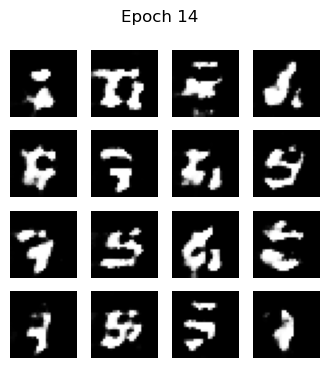

Time for epoch 14 is 166.93 sec


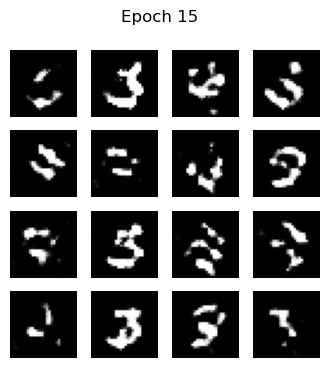

Time for epoch 15 is 168.14 sec


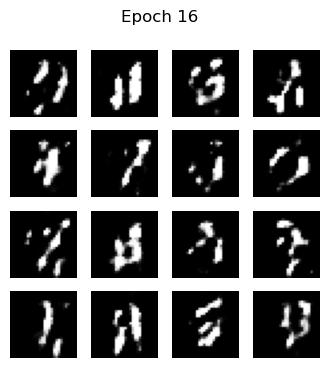

Time for epoch 16 is 166.19 sec


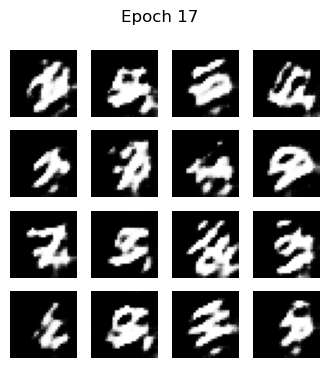

Time for epoch 17 is 166.43 sec


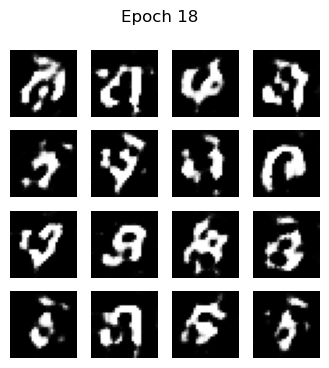

Time for epoch 18 is 166.61 sec


KeyboardInterrupt: 

In [4]:
# ==========================================
# Steps 3, 4 & 5: Training Loop Details
# ==========================================
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

# Seed to keep the same generated images across epochs for visualization
seed = tf.random.normal([num_examples_to_generate, noise_dim])

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generate images
        generated_images = generator(noise, training=True)

        # Evaluate real and fake images
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Step 3 & 4: Calculate losses
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Calculate gradients
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Apply gradients (Update parameters)
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

def generate_and_save_images(model, epoch, test_input):
    # Notice `training` is set to False.
    # This is so all layers run in inference mode (batchnorm).
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        # Rescale from [-1, 1] to [0, 255] for plotting
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Epoch {epoch}")
    plt.show()

# Step 5: Iterate between Discriminator and Generator training
def train(dataset, epochs):
    print("Starting Training Loop...")
    for epoch in range(epochs):
        start = time.time()

        for image_batch in dataset:
            train_step(image_batch)

        # Produce images for the GIF/visualization as we go
        generate_and_save_images(generator, epoch + 1, seed)

        print(f'Time for epoch {epoch + 1} is {time.time()-start:.2f} sec')

    # Generate final images
    generate_and_save_images(generator, epochs, seed)

# Run the training
train(train_dataset, EPOCHS)